# IPCA – Histórico Geral (IBGE/SIDRA 1737)

Este notebook apresenta:

**1. O que é o IPCA geral**  
**2. Como o IBGE organiza a tabela 1737**  
**3. Execução do pipeline (IBGE – tabela 1737)**  
**4. Consulta ao banco de dados**  
**5. Gráficos e análises profissionais**  

Vamos começar entendendo o conceito.

# 1. O que é o IPCA geral?

O **IPCA (Índice Nacional de Preços ao Consumidor Amplo)** é o índice oficial de inflação do Brasil.

- é a referência do regime de metas de inflação  
- é usado em contratos, títulos públicos e projeções macroeconômicas  
- mede a variação de preços para famílias com renda entre 1 e 40 salários mínimos  

A série histórica completa do IPCA geral é disponibilizada pelo IBGE na **tabela 1737 do SIDRA**, desde 1980.

# 2. Tabela 1737 – variáveis principais

A tabela 1737 contém várias métricas do IPCA geral. As que usamos aqui são:

- **63**   → variação mensal (%), que chamaremos de `indice`  
- **2266** → número-índice (base dez/1993 = 100), `nIndice`  
- **69**   → acumulado no ano (%), `acumulado`  
- **2265** → acumulado em 12 meses (%), `acumulado12m`  

Nosso pipeline já consulta essas quatro variáveis e monta a tabela `bcb.ipca`.

# 3. Ajustar o PYTHONPATH para importar `src/`

In [6]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 4. Importações

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.ipca import run_ipca
from src.database.connection import engine

pd.set_option("display.float_format", "{:.6f}".format)

# 5. Executar pipeline IPCA geral (IBGE)

Isso irá:
- consultar a tabela 1737 do SIDRA  
- baixar as variáveis 63, 2266, 69 e 2265  
- criar/atualizar a tabela `bcb.ipca`  
- inserir todos os dados no PostgreSQL

In [3]:
run_ipca()

2026-04-20 12:34:15,896 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=1737, variavel=63, periodo=all
2026-04-20 12:34:20,349 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.
2026-04-20 12:34:20,351 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=1737, variavel=2266, periodo=all
2026-04-20 12:34:21,176 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.
2026-04-20 12:34:21,181 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=1737, variavel=69, periodo=all
2026-04-20 12:34:22,084 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.
2026-04-20 12:34:22,086 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=1737, variavel=2265, periodo=all
2026-04-20 12:34:26,303 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.


Tabela bcb.ipca atualizada com sucesso!


# 6. Verificar tabelas existentes no schema `bcb`

In [4]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,ipca_alimentacao
2,ipca_habitacao
3,selic_meta
4,selic_over


# 7. Carregar dados do IPCA geral

In [10]:
query_real = """
select *
from bcb.ipca
where date >= '1996-01-01'
order by date desc;
"""

df_real = pd.read_sql(query_real, engine)

query_ipca = """
select *
from bcb.ipca
order by date desc;
"""

df = pd.read_sql(query_ipca, engine)
df.head()

,date,indice,nIndice,acumulado,acumulado12m
0,2026-03-01,0.880000,7545.530000,1.920000,4.140000
1,2026-03-01,0.880000,7545.530000,1.920000,4.140000
2,2026-02-01,0.700000,7479.710000,1.030000,3.810000
3,2026-02-01,0.700000,7479.710000,1.030000,3.810000
4,2026-01-01,0.330000,7427.720000,0.330000,4.440000


# 8. Primeiros valores

In [11]:
df_real.tail(12)

,date,indice,nIndice,acumulado,acumulado12m
714,1996-06-01,1.190000,1325.840000,6.560000,16.260000
715,1996-06-01,1.190000,1325.840000,6.560000,16.260000
716,1996-05-01,1.220000,1310.250000,5.310000,17.490000
717,1996-05-01,1.220000,1310.250000,5.310000,17.490000
718,1996-04-01,1.260000,1294.460000,4.040000,19.170000
719,1996-04-01,1.260000,1294.460000,4.040000,19.170000
720,1996-03-01,0.350000,1278.350000,2.740000,20.550000
721,1996-03-01,0.350000,1278.350000,2.740000,20.550000
722,1996-02-01,1.030000,1273.890000,2.380000,21.990000
723,1996-02-01,1.030000,1273.890000,2.380000,21.990000


# 9. Estatísticas básicas

In [13]:
df_real.describe()

,date,indice,nIndice,acumulado,acumulado12m
count,726,726.000000,726.000000,726.000000,726.000000
mean,2011-01-30 21:09:25.289256,0.498567,3671.815427,3.418953,6.417824
min,1996-01-01 00:00:00,-0.680000,1260.900000,-0.160000,1.650000
25%,2003-07-08 18:00:00,0.250000,2181.432500,1.650000,4.445000
50%,2011-02-01 00:00:00,0.450000,3248.200000,3.090000,5.840000
75%,2018-08-24 06:00:00,0.690000,5075.900000,4.722500,7.490000
max,2026-03-01 00:00:00,3.020000,7545.530000,12.530000,21.990000
std,NaN,0.399412,1810.901199,2.245426,3.264408


# 10. Gráfico da variação mensal do IPCA

A série `indice` representa a **variação mensal (%)** do IPCA geral.

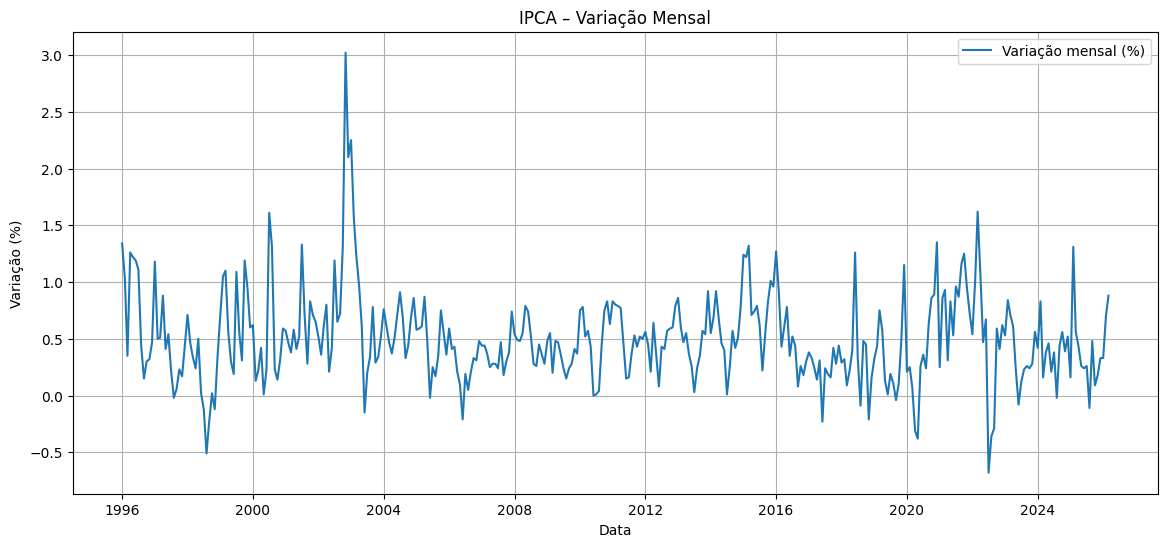

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(df_real["date"], df_real["indice"], label="Variação mensal (%)")

plt.title("IPCA – Variação Mensal")
plt.xlabel("Data")
plt.ylabel("Variação (%)")
plt.grid(True)
plt.legend()
plt.show()

# 11. IPCA acumulado em 12 meses

A série `acumulado12m` é a métrica mais usada pelo Banco Central para avaliar a inflação corrente.

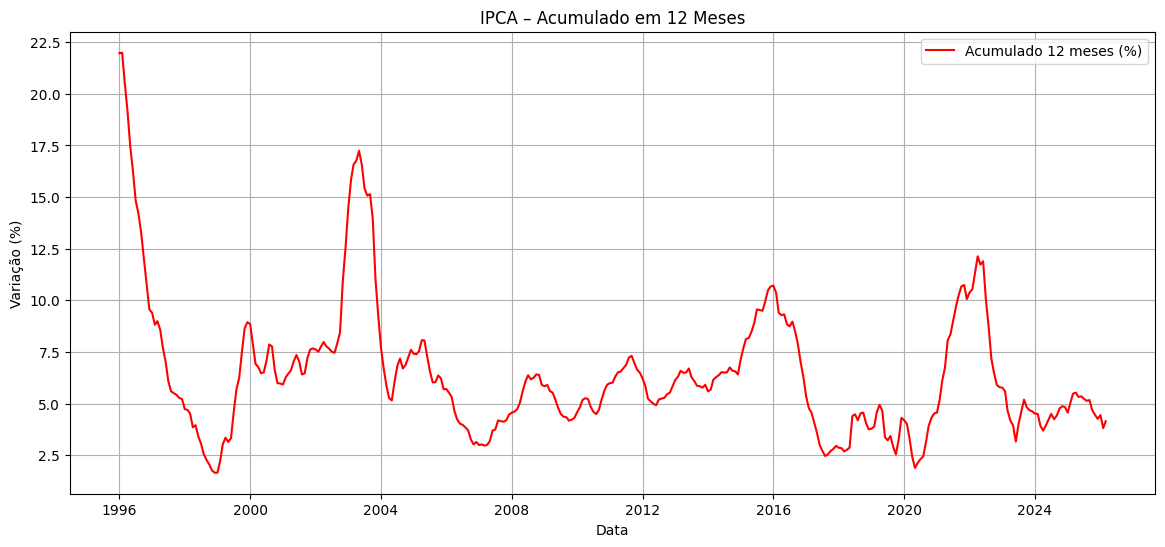

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(df_real["date"], df_real["acumulado12m"], label="Acumulado 12 meses (%)", color="red")

plt.title("IPCA – Acumulado em 12 Meses")
plt.xlabel("Data")
plt.ylabel("Variação (%)")
plt.grid(True)
plt.legend()
plt.show()

# 12. Heatmap dos últimos 24 meses (variação mensal)

Útil para visualizar aceleração e desaceleração da inflação.

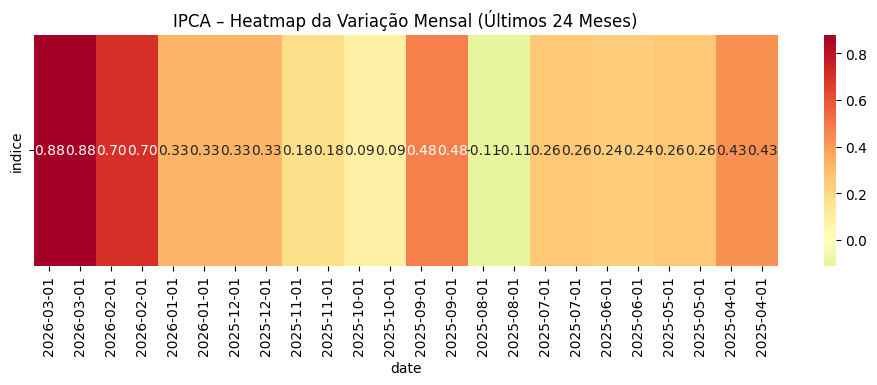

In [19]:
df_real["date"] = df_real["date"].dt.date
df_hm = df_real.set_index("date").head(24)

plt.figure(figsize=(12, 3))
sns.heatmap(
    df_hm[["indice"]].T,
    cmap="RdYlGn_r",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("IPCA – Heatmap da Variação Mensal (Últimos 24 Meses)")
plt.show()

# 13. Média móvel de 12 meses da variação mensal

Ajuda a visualizar tendências estruturais da inflação.

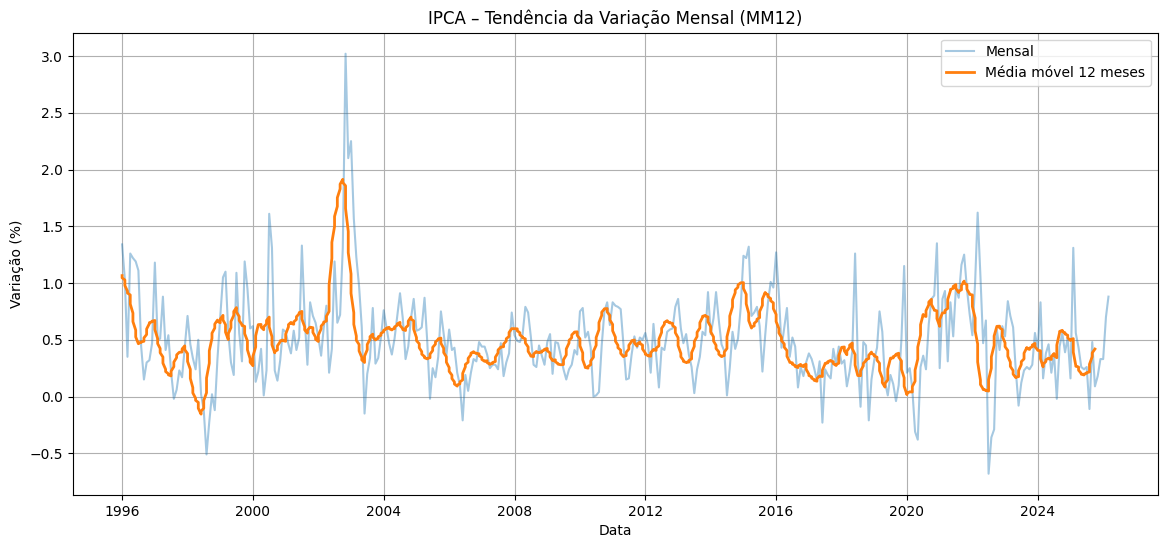

In [17]:
df_real["mm12"] = df_real["indice"].rolling(12).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_real["date"], df_real["indice"], alpha=0.4, label="Mensal")
plt.plot(df_real["date"], df_real["mm12"], linewidth=2, label="Média móvel 12 meses")

plt.title("IPCA – Tendência da Variação Mensal (MM12)")
plt.xlabel("Data")
plt.ylabel("Variação (%)")
plt.grid(True)
plt.legend()
plt.show()

# 14. Conclusões

- O IPCA geral é a principal medida de inflação do Brasil.  
- A tabela 1737 do SIDRA permite reconstruir a série desde 1980.  
- As variáveis `indice`, `nIndice`, `acumulado` e `acumulado12m` cobrem os principais usos macroeconômicos.  
- A tabela `bcb.ipca` agora está padronizada e atualizada pelo pipeline.  

Próximos passos:
- Integrar os 9 grupos (tabela 7060) com o IPCA geral  
- Construir decomposições por grupo e subgrupo  
- Criar análises de núcleos, difusão e projeções de inflação  